#### [ 닮은 꼴 연예인 찾기 모델 ] 

- RestNet을 fine-tuning 해서 아이돌 멤버 분류모델 생성
- 새로운 이미지로 닮은 연예인 멤버 예측

[1] 모듈 로딩 및 데이터 준비<hr>

In [45]:
# [1-1] 모듈 로딩
import os, glob, random, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda import amp
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 기본 모듈
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# PyTorch 관련
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

# 전이학습 모델 관련
from torchvision.models import vgg16, resnet18, resnet50, resnet101
from torchvision.models import VGG16_Weights
from torchvision.models import ResNet18_Weights, ResNet50_Weights, ResNet101_Weights

# 데이터 분리
from sklearn.model_selection import train_test_split

# 이미지 확인
from PIL import Image


In [46]:
## [1-1] 모듈 로딩 및 재현성 설정
def set_seed(seed:int=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

set_seed(42)

In [47]:
# [1-2] 경로 및 하이퍼파라미터 
DATA_ROOT     = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\total_idol_faces"
NEW_IMAGE_DIR = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\New_image"
OUTPUT_DIR    = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\outputs"     # 체크포인트/임베딩 저장

# 학습 설정
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 5e-4
VAL_RATIO  = 0.2
SEED       = 42

# 데이터 검증/필터링
VALID_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
MIN_IMAGES_PER_ID = 5
MAX_IMAGES_PER_ID = None

# 출력 경로 준비
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=== 설정 정보 ===")
print(f"Device: {DEVICE}")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LR}")
print(f"Data Root: {DATA_ROOT}")

=== 설정 정보 ===
Device: cuda
Image Size: 224
Batch Size: 32
Epochs: 100
Learning Rate: 0.0005
Data Root: C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\total_idol_faces


In [48]:
## [1-3] 모델 관련 설정(백본/가중치/전처리)
# 백본 선택 : 'resnet50' / 'resnet101' 
BACKBONE = "resnet50"

# ImageNet 사전학습 가중치 (전처리/정규화 정보 포함)
if BACKBONE == "resnet50":
    R_WEIGHTS = ResNet50_Weights.IMAGENET1K_V2
    backbone_ctor = resnet50
elif BACKBONE == "resnet101":
    R_WEIGHTS = ResNet101_Weights.IMAGENET1K_V2
    backbone_ctor = resnet101
elif BACKBONE == "resnet18":
    R_WEIGHTS = ResNet18_Weights.IMAGENET1K_V1
else:
    raise ValueError("지원하지 않는 BACKBONE")

# 전처리(정규화/리사이즈) : 평가용
EVAL_TRANSFROM = R_WEIGHTS.transforms(antialias=True)

# 학습용 변환(얼굴 : 밝기/대비/좌우반전)
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=R_WEIGHTS.meta['mean'], std=R_WEIGHTS.meta['std']),
])

INFER_TRANSFORM = transforms.COmpose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=R_WEIGHTS.meta["mean"], std=R_WEIGHTS.meta["std"])
])

print("Backbone:", BACKBONE)

KeyError: 'mean'

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

[2] 이미지 전처리 준비<hr>

In [ ]:
# ## [2-1] 모델에 사용할 이미지 전처리
# import os, cv2
# import mediapipe as mp

# SRC_ROOT = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\second_idol"
# DST_ROOT = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\second_idol_faces"
# os.makedirs(DST_ROOT, exist_ok=True)


# mp_fd = mp.solutions.face_detection
# fd = mp_fd.FaceDetection(model_selection=1, min_detection_confidence=0.5)  # 원거리 얼굴엔 model_selection=1

# VALID_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
# RESIZE_TO = (224, 224)

# def ensure_dir(p): os.makedirs(p, exist_ok=True)

# def process_image(src_path, dst_dir, base_name):
#     img = cv2.imread(src_path)
#     if img is None:
#         print(f"[SKIP read error] {src_path}")
#         return 0

#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     res = fd.process(img_rgb)
#     if not res.detections:
#         print(f"[NO FACE] {src_path}")
#         return 0

#     h, w = img.shape[:2]
#     saved = 0
#     for i, det in enumerate(res.detections):
#         bbox = det.location_data.relative_bounding_box
#         x1 = max(0, int(bbox.xmin * w))
#         y1 = max(0, int(bbox.ymin * h))
#         x2 = min(w-1, int((bbox.xmin + bbox.width) * w))
#         y2 = min(h-1, int((bbox.ymin + bbox.height) * h))

#         pad = int(0.1 * max(x2-x1, y2-y1))
#         xx1 = max(0, x1 - pad); yy1 = max(0, y1 - pad)
#         xx2 = min(w-1, x2 + pad); yy2 = min(h-1, y2 + pad)

#         crop = img[yy1:yy2, xx1:xx2]
#         if RESIZE_TO:
#             crop = cv2.resize(crop, RESIZE_TO, interpolation=cv2.INTER_AREA)
#         cv2.imwrite(os.path.join(dst_dir, f"{base_name}_face{i}.jpg"), crop)
#         saved += 1
#     return saved

# def main():
#     total_imgs, total_saved = 0, 0
#     for root, _, files in os.walk(SRC_ROOT):
#         rel_dir = os.path.relpath(root, SRC_ROOT)
#         dst_dir = os.path.join(DST_ROOT, rel_dir) if rel_dir != "." else DST_ROOT
#         ensure_dir(dst_dir)
#         for fname in files:
#             ext = os.path.splitext(fname)[1].lower()
#             if ext not in VALID_EXTS: 
#                 continue
#             total_imgs += 1
#             src_path  = os.path.join(root, fname)
#             base_name = os.path.splitext(fname)[0]
#             total_saved += process_image(src_path, dst_dir, base_name)

#     print(f"Scanned: {total_imgs}, Saved faces: {total_saved}, Out: {DST_ROOT}")

# if __name__ == "__main__":
#     main()


In [ ]:
# [2-1] 데이터 전처리
def build_transforms(img_size=224, use_aug=True):
    tf_train = transforms.Compose([
        transforms.Resize((img_size,img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
    ])
    tf_val = transforms.Compose([
        transforms.Resize((img_size,img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
    ])
    return tf_train, tf_val


In [ ]:
## [2-2] 데이터셋 정의
class IdolMemberDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self): 
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform: 
            img = self.transform(img)
        return img, self.labels[idx], self.filepaths[idx]

In [ ]:
## [2-3] 데이터 불러오기

def load_dataset_flat(root_dir: str, img_size=224, val_ratio=0.2, seed=42):
    base = datasets.ImageFolder(root_dir)  # transform=None
    if len(base) == 0:
        raise RuntimeError("DATA_ROOT에 이미지가 없습니다.")

    classes      = base.classes
    class_to_idx = base.class_to_idx
    samples      = base.samples  # list of (path, label)

    # 전체 경로/라벨
    all_paths = [p for p,_ in samples]
    all_lbls  = [y for _,y in samples]

    # stratified split
    tr_idx, va_idx = train_test_split(
        np.arange(len(all_paths)),
        test_size=val_ratio,
        stratify=all_lbls,
        random_state=seed
    )
    tr_files = [all_paths[i] for i in tr_idx]
    tr_lbls  = [all_lbls[i]  for i in tr_idx]
    va_files = [all_paths[i] for i in va_idx]
    va_lbls  = [all_lbls[i]  for i in va_idx]

    tf_train, tf_val = build_transforms(img_size)
    train_ds = IdolMemberDataset(tr_files, tr_lbls, tf_train)
    val_ds   = IdolMemberDataset(va_files, va_lbls, tf_val)

    print(f"총 이미지: {len(all_paths)} | 클래스 수: {len(classes)}")
    print(f"train: {len(train_ds)} | valid: {len(val_ds)}")
    return train_ds, val_ds, classes, class_to_idx

train_ds, val_ds, classes, class_to_idx = load_dataset_flat(DATA_ROOT, IMG_SIZE, VAL_RATIO, SEED)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("클래스 수:", len(classes))
print("예시 클래스:", classes[:5])


총 이미지: 16415 | 클래스 수: 82
train: 13132 | valid: 3283
클래스 수: 82
예시 클래스: ['2AM-jokwon', '2AM-slong', '2NE1_cl', '2NE1_minji', '2NE1_sandarapark']


[3] 모델 정의 (ResNet) <hr>

In [ ]:
## [3-1] 모델 정의(ResNet18 + FC 교체)
def build_resnet18(num_classes: int, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    return model

model = build_resnet18(len(classes), freeze_backbone=True).to(DEVICE)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[4] 학습/검증 관련 함수 <hr>

In [ ]:
# [4-1] 학습 관련 함수
import torch
import torch.nn as nn
import torch.optim as optim

def unpack_batch(batch):
    """DataLoader가 (x,y,*extras) 또는 dict로 줄 때에도 안전하게 x,y만 꺼낸다."""
    if isinstance(batch, (list, tuple)):
        if len(batch) < 2:
            raise ValueError(f"Batch has <2 elements: {type(batch)} length={len(batch)}")
        x, y = batch[0], batch[1]          # 나머지 필드는 무시
    elif isinstance(batch, dict):
        # 흔한 키 우선순위로 탐색
        x = batch.get('x') or batch.get('image') or batch.get('images')
        y = batch.get('y') or batch.get('label') or batch.get('labels')
        if x is None or y is None:
            raise ValueError(f"Dict batch missing image/label keys: {batch.keys()}")
    else:
        raise ValueError(f"Unsupported batch type: {type(batch)}")
    return x, y

def ensure_class_indices(y):
    """y가 원-핫(one-hot) 혹은 float일 경우 정수 클래스 인덱스로 변환."""
    if y.dtype in (torch.float16, torch.float32, torch.float64):
        if y.ndim == 2:  # one-hot -> argmax
            return y.argmax(dim=1)
    return y

def run_epoch(model, loader, criterion, optimizer=None, device="cuda", use_amp=None):
    if use_amp is None:
        use_amp = (device == "cuda")
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), ensure_class_indices(y.to(device))

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss   = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_seen    += x.size(0)

    avg_loss = total_loss / max(1, total_seen)
    avg_acc  = total_correct / max(1, total_seen)
    return avg_loss, avg_acc

def train_quick(model, train_dl, val_dl, device="cuda", epochs=10, lr=1e-3, weight_decay=1e-4, use_amp=None):
    if use_amp is None:
        use_amp = (device == "cuda")
    criterion = nn.CrossEntropyLoss()
    # 분류기만 학습하려면 아래 줄로:
    # optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=weight_decay)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=weight_decay)

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, device, use_amp)
        va_loss, va_acc = run_epoch(model, val_dl,   criterion, None,      device, use_amp)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
        print(f"[{ep:02d}/{epochs}] Train {tr_loss:.4f}/{tr_acc:.4f} | Val {va_loss:.4f}/{va_acc:.4f}")
    return hist

HISTORY = train_quick(model, train_dl, val_dl, device=DEVICE, epochs=10, lr=1e-3)

C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_25160\1411890516.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_25160\1411890516.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[01/10] Train 3.9281/0.0959 | Val 3.5266/0.1575
[02/10] Train 3.2689/0.2093 | Val 3.2123/0.2083
[03/10] Train 2.9896/0.2601 | Val 3.0817/0.2422
[04/10] Train 2.8273/0.2926 | Val 2.9864/0.2586
[05/10] Train 2.7307/0.3090 | Val 2.9951/0.2549
[06/10] Train 2.6217/0.3281 | Val 2.9222/0.2818
[07/10] Train 2.5683/0.3491 | Val 2.8627/0.2888
[08/10] Train 2.5352/0.3498 | Val 2.8718/0.2793
[09/10] Train 2.4753/0.3623 | Val 2.8896/0.2912
[10/10] Train 2.4429/0.3726 | Val 2.8681/0.2836


[5] 학습 실행 <hr>

In [ ]:
# ## [5-1] 학습 실행
# # === Minimal ResNet18 Fine-tune (aim: Val Acc >= 0.5) ===
# import os, random, numpy as np
# from pathlib import Path
# from collections import Counter

# import torch, torch.nn as nn, torch.optim as optim
# from torch.utils.data import DataLoader, WeightedRandomSampler
# from torchvision import datasets, transforms, models
# from sklearn.model_selection import train_test_split

# # ----- 기본 설정 (이미 정의된 변수가 있으면 그대로 사용) -----
# try: DEVICE
# except NameError: DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# try: DATA_ROOT
# except NameError: DATA_ROOT = r"C:\Users\KDT-57-\OneDrive\Desktop\KDT9\[10] DL\PROJECT\second_idol_faces"

# IMG_SIZE   = 224
# BATCH_SIZE = 32
# VAL_RATIO  = 0.2
# SEED       = 42

# EPOCHS_S1  = 8   # FC만
# EPOCHS_S2  = 15  # layer4 + FC
# LR_HEAD_S1 = 1e-3
# LR_HEAD_S2 = 5e-4
# LR_BB_S2   = 1e-4
# WEIGHT_DECAY = 1e-4
# USE_AMP      = True  # CUDA면 자동 활성

# # ----- Seed -----
# random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

# # ----- Transforms (ImageNet 통계) -----
# tf_train = transforms.Compose([
#     transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0), ratio=(0.9,1.1)),
#     transforms.RandomHorizontalFlip(0.5),
#     transforms.ColorJitter(0.25,0.25,0.25,0.1),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
# ])
# tf_val = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
# ])

# # ----- 데이터 로드 & Stratified Split -----
# base = datasets.ImageFolder(DATA_ROOT)  # transform=None (경로/라벨만)
# assert len(base) > 0, "DATA_ROOT에 이미지가 없습니다."

# classes      = base.classes
# class_to_idx = base.class_to_idx
# paths        = [p for p,_ in base.samples]
# labels       = [y for _,y in base.samples]

# tr_idx, va_idx = train_test_split(
#     np.arange(len(paths)), test_size=VAL_RATIO,
#     stratify=labels, random_state=SEED
# )
# tr_files = [paths[i] for i in tr_idx]; tr_lbls = [labels[i] for i in tr_idx]
# va_files = [paths[i] for i in va_idx]; va_lbls = [labels[i] for i in va_idx]

# from PIL import Image
# class SimpleDS(torch.utils.data.Dataset):
#     def __init__(self, files, labs, transform):
#         self.files, self.labs, self.tf = files, labs, transform
#     def __len__(self): return len(self.files)
#     def __getitem__(self, i):
#         img = Image.open(self.files[i]).convert("RGB")
#         return self.tf(img), self.labs[i]

# train_ds, val_ds = SimpleDS(tr_files, tr_lbls, tf_train), SimpleDS(va_files, va_lbls, tf_val)

# # 불균형 완화: inverse-frequency sampler + class weight
# cnt = Counter(tr_lbls)
# num_classes = len(classes)
# freq = np.array([cnt.get(i,0) for i in range(num_classes)], dtype=np.float32)
# inv_freq = 1.0 / np.maximum(freq, 1.)
# sample_w = np.array([inv_freq[y] for y in tr_lbls], dtype=np.float32)

# sampler  = WeightedRandomSampler(weights=torch.from_numpy(sample_w), num_samples=len(sample_w), replacement=True)
# train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=(DEVICE=="cuda"))
# val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=(DEVICE=="cuda"))

# print(f"총 이미지: {len(paths)} | 클래스: {num_classes}")
# print(f"Train: {len(train_ds)} | Valid: {len(val_ds)}")

# # ----- 모델 (ResNet18) -----
# weights = models.ResNet18_Weights.IMAGENET1K_V1
# model   = models.resnet18(weights=weights)
# model.fc = nn.Linear(model.fc.in_features, num_classes)
# model = model.to(DEVICE)

# # 역빈도 class weight (+ label smoothing)
# class_weight = torch.tensor([(freq.sum() / max(f,1.)) for f in freq], dtype=torch.float32)
# class_weight = (class_weight / class_weight.mean()).to(DEVICE)
# criterion = nn.CrossEntropyLoss(weight=class_weight, label_smoothing=0.05)

# # ----- Epoch 러너 -----
# def run_epoch(model, loader, optimizer=None):
#     train_mode = optimizer is not None
#     model.train() if train_mode else model.eval()
#     scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

#     tot_loss, tot_correct, tot_seen = 0.0, 0, 0
#     for x, y in loader:
#         x, y = x.to(DEVICE), y.to(DEVICE)
#         if train_mode: optimizer.zero_grad(set_to_none=True)
#         with torch.cuda.amp.autocast(enabled=USE_AMP):
#             logits = model(x)
#             loss   = criterion(logits, y)
#         if train_mode:
#             scaler.scale(loss).backward()
#             scaler.step(optimizer); scaler.update()
#         tot_loss    += loss.item() * x.size(0)
#         tot_correct += (logits.argmax(1) == y).sum().item()
#         tot_seen    += x.size(0)
#     return tot_loss / max(1, tot_seen), tot_correct / max(1, tot_seen)

# # ----- Stage-1: FC만 학습 -----
# for p in model.parameters(): p.requires_grad = False
# for p in model.fc.parameters(): p.requires_grad = True
# opt1 = optim.Adam(model.fc.parameters(), lr=LR_HEAD_S1, weight_decay=WEIGHT_DECAY)

# print("\n[S1] FC만 학습 시작")
# best_val, best_state = -1.0, None
# for ep in range(1, EPOCHS_S1+1):
#     tr_loss, tr_acc = run_epoch(model, train_dl, optimizer=opt1)
#     va_loss, va_acc = run_epoch(model, val_dl,   optimizer=None)
#     print(f"[S1 {ep:02d}] Train {tr_loss:.4f}/{tr_acc:.4f} | Val {va_loss:.4f}/{va_acc:.4f}")
#     if va_acc > best_val:
#         best_val, best_state = va_acc, {k:v.cpu() for k,v in model.state_dict().items()}

# # ----- Stage-2: layer4 + FC 미세조정 -----
# if best_state: model.load_state_dict(best_state, strict=False)
# for p in model.parameters(): p.requires_grad = False
# for p in model.layer4.parameters(): p.requires_grad = True
# for p in model.fc.parameters():     p.requires_grad = True
# opt2 = optim.Adam([
#     {"params": model.fc.parameters(),     "lr": LR_HEAD_S2},
#     {"params": model.layer4.parameters(), "lr": LR_BB_S2},
# ], weight_decay=WEIGHT_DECAY)

# print("\n[S2] layer4 + FC 미세조정 시작")
# for ep in range(1, EPOCHS_S2+1):
#     tr_loss, tr_acc = run_epoch(model, train_dl, optimizer=opt2)
#     va_loss, va_acc = run_epoch(model, val_dl,   optimizer=None)
#     print(f"[S2 {ep:02d}] Train {tr_loss:.4f}/{tr_acc:.4f} | Val {va_loss:.4f}/{va_acc:.4f}")
#     if va_acc > best_val:
#         best_val, best_state = va_acc, {k:v.cpu() for k,v in model.state_dict().items()}

# if best_state: model.load_state_dict(best_state, strict=False)
# print(f"\n== 최종 최고 Val Acc: {best_val:.4f} ==")



In [ ]:
# [5-1] 학습/검증 곡선 시각화
def train_model(model, train_dl, val_dl, epochs=100, lr=1e-4, device=DEVICE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=lr)

    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = run_epoch(model, train_dl, optimizer, criterion, device=device)
        va_loss, va_acc = run_epoch(model, val_dl, criterion, device=device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"[{ep:02d}/{epochs}] Train {tr_loss:.4f}/{tr_acc:.4f} | Valid {va_loss:.4f}/{va_acc:.4f}")

    return model, history



                       precision    recall  f1-score   support

           2AM-jokwon      0.730     0.675     0.701        40
            2AM-slong      0.321     0.450     0.375        40
              2NE1_cl      0.452     0.475     0.463        40
           2NE1_minji      0.400     0.100     0.160        40
     2NE1_sandarapark      0.400     0.150     0.218        40
         2PM_chansung      0.286     0.500     0.364        40
            2PM_junho      0.462     0.150     0.226        40
         2PM_tackyeon      0.667     0.100     0.174        40
         2PM_wooyoung      0.287     0.725     0.411        40
             AOA_choa      0.885     0.575     0.697        40
            AOA_jimin      0.333     0.050     0.087        40
         AOA_sulhyeon      0.200     0.025     0.044        40
            B1A4_baro      0.312     0.125     0.179        40
        B1A4_jinyoung      0.192     0.250     0.217        40
       CNBLUE_yonghwa      0.289     0.289     0.289  

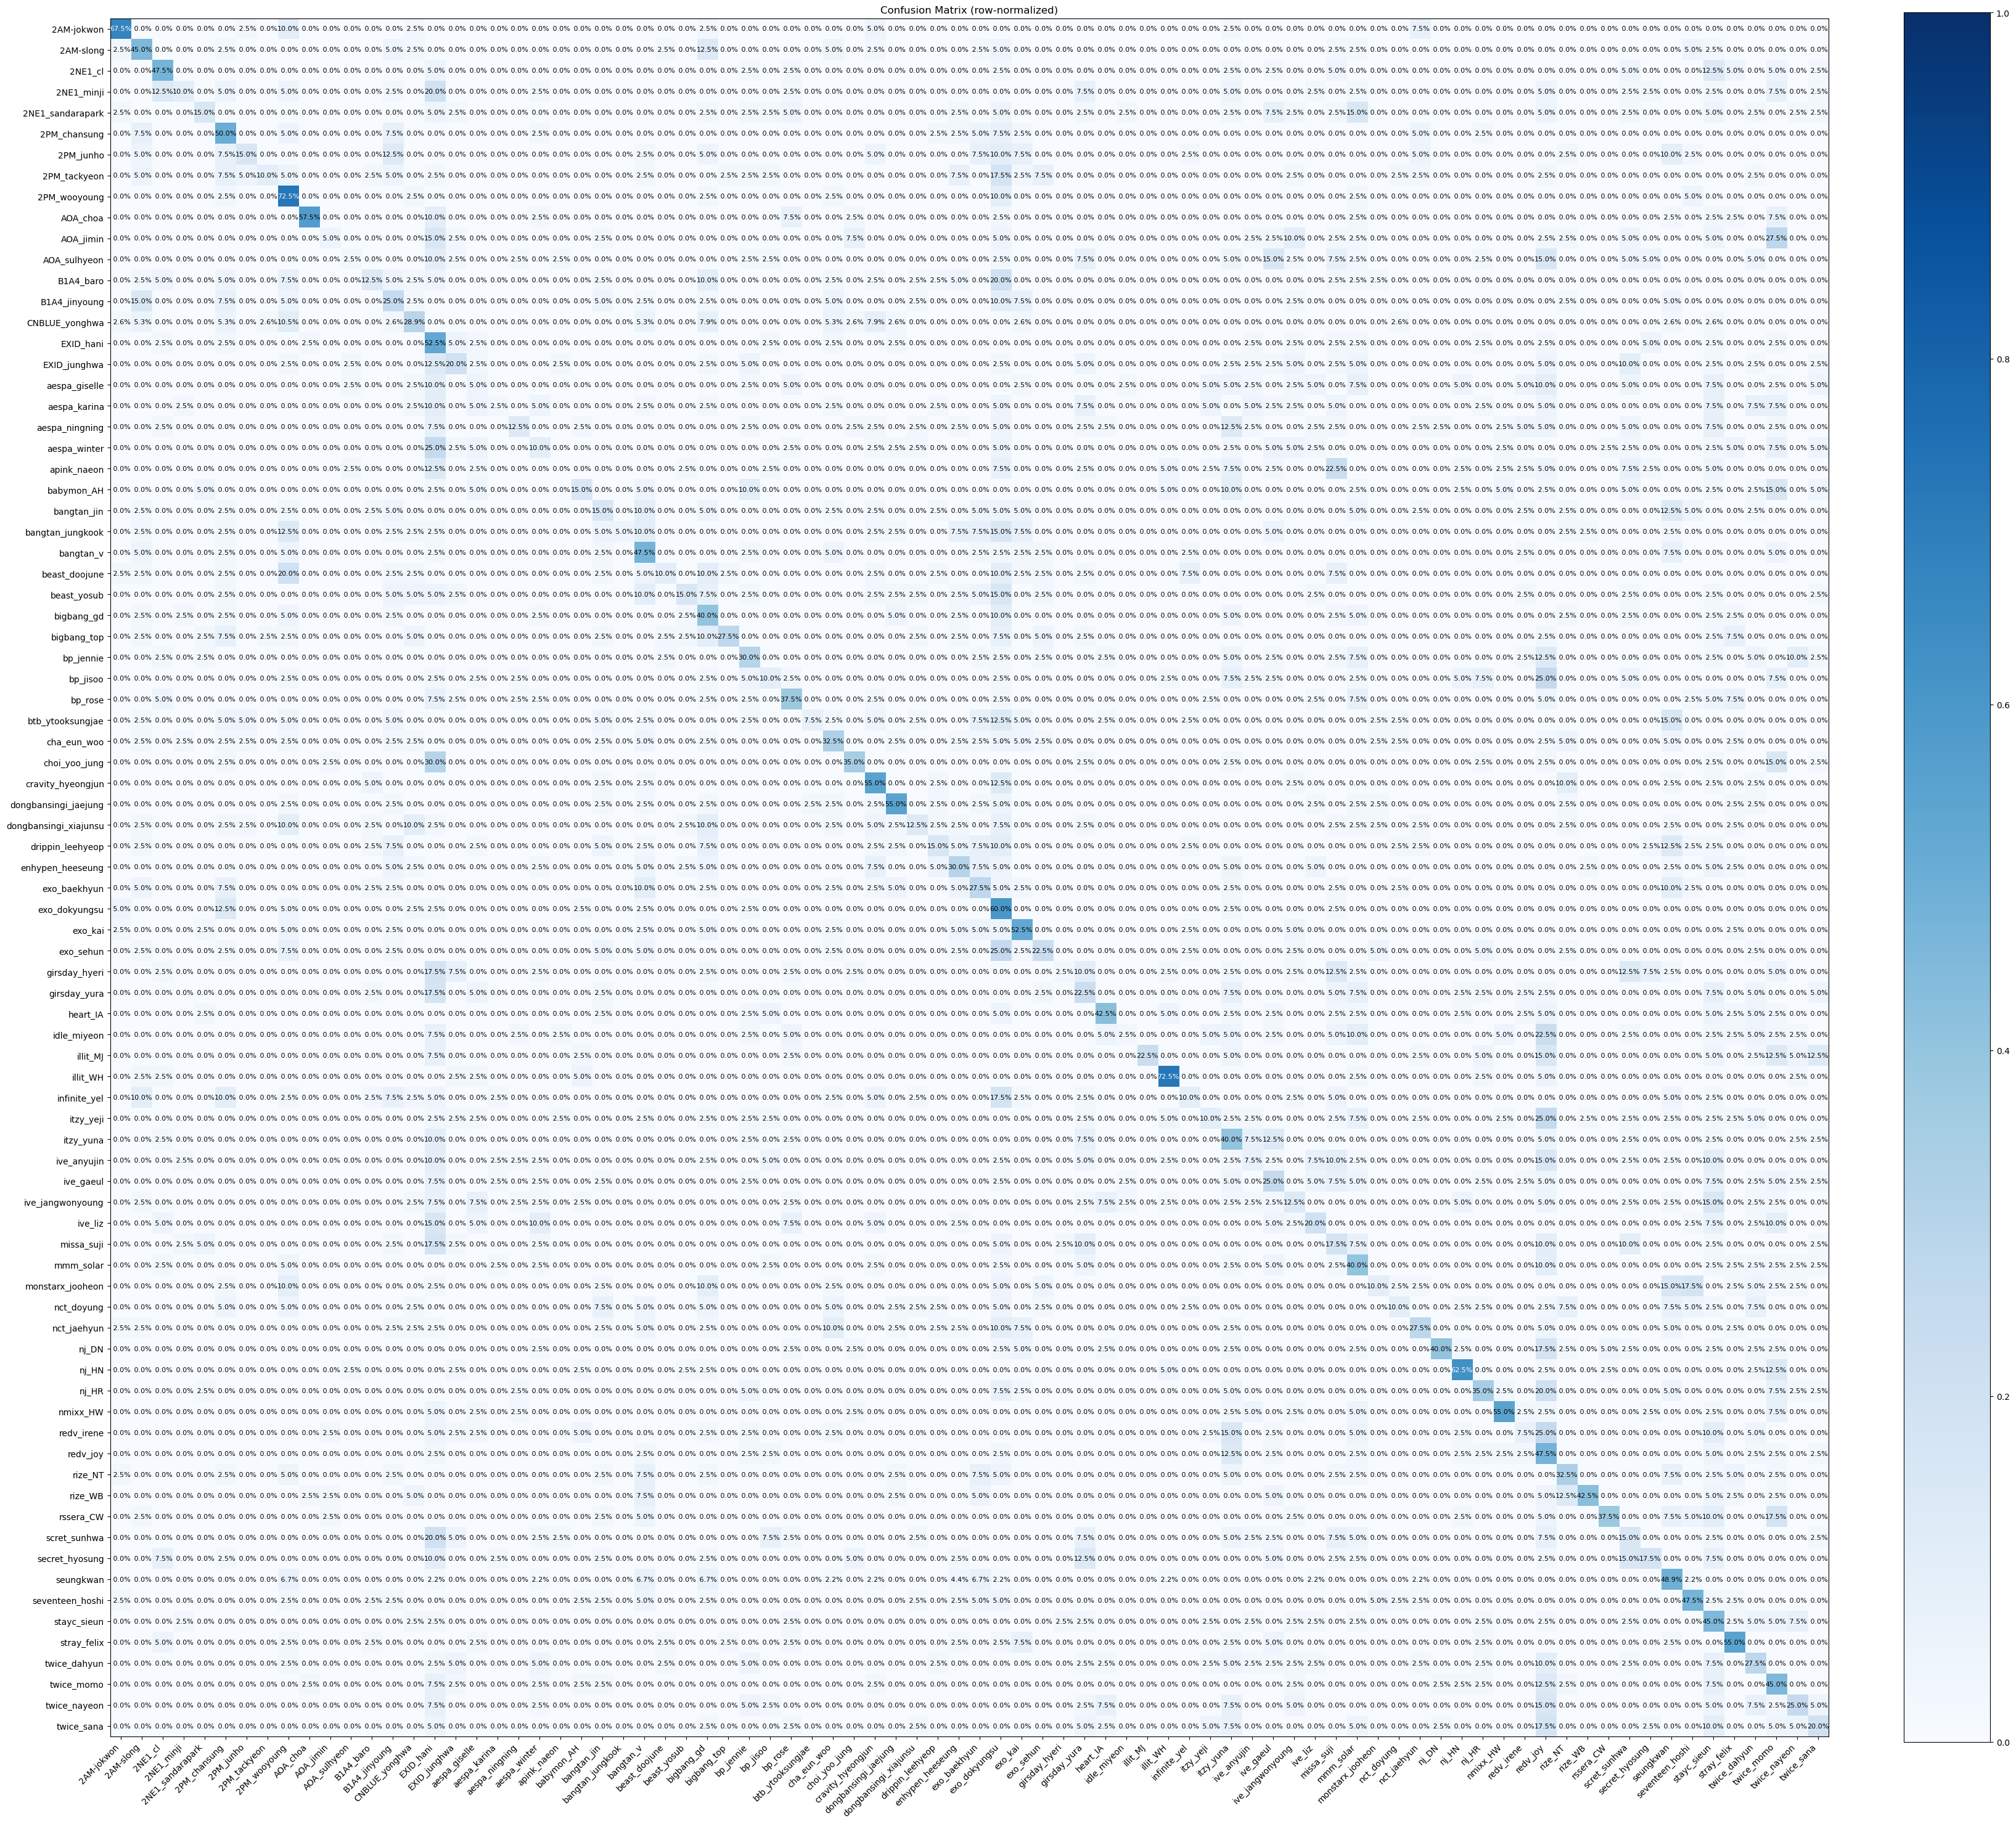

In [ ]:
# [5-2] 혼동행렬 & 리포트
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def collect_preds(model, loader, device=DEVICE):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labs, _p in loader:
        imgs, labs = imgs.to(device), labs.to(device)
        logits = model(imgs)
        y_true.extend(labs.cpu().tolist())
        y_pred.extend(logits.argmax(1).cpu().tolist())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_preds(model, val_dl, device=DEVICE)
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
print(classification_report(y_true, y_pred, target_names=classes[:len(set(y_true))], digits=3, zero_division=0))

def plot_cm(cm, classes):
    cmn = cm / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(max(8, len(classes)*0.4), max(8, len(classes)*0.4)))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    for i in range(cmn.shape[0]):
        for j in range(cmn.shape[1]):
            ax.text(j, i, f"{cmn[i,j]*100:4.1f}%", ha="center", va="center",
                    color=("white" if cmn[i,j]>0.6 else "black"), fontsize=8)
    ax.set_title("Confusion Matrix (row-normalized)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

plot_cm(cm, classes)


[6] 닮은꼴 연예인 찾기 시각화 <hr>

In [ ]:
# [6-1] 대표 이미지 함수 & 확장자 체크
def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in VALID_EXTS

def sample_image_of_class(root_dir: str, class_name: str) -> str:
    """
    DATA_ROOT/class_name/ 아래 이미지 하나 샘플로 반환
    """
    cdir = Path(root_dir) / class_name
    if not cdir.is_dir(): 
        return ""
    for f in cdir.rglob("*"):
        if is_image(f):
            return str(f)
    return ""



== [0] de.jpg ==


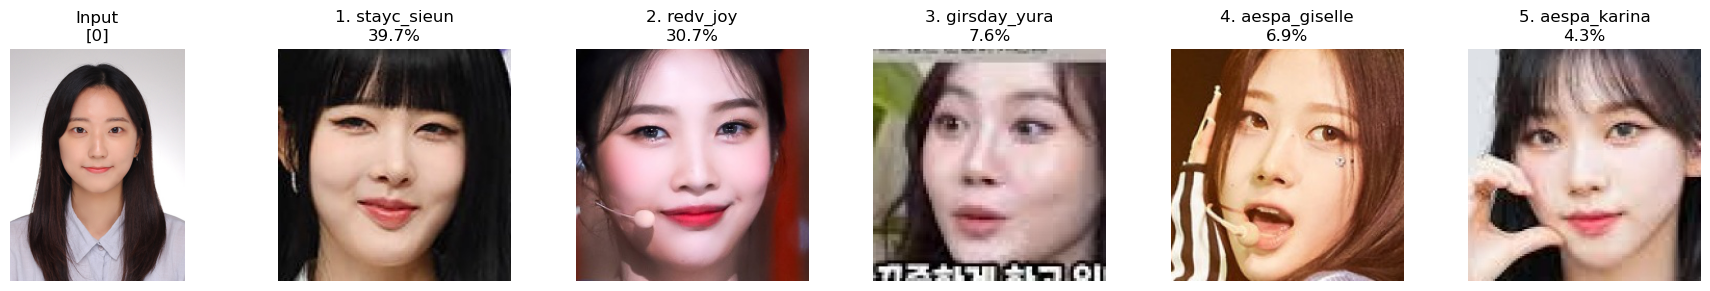


== [1] hr.jpg ==


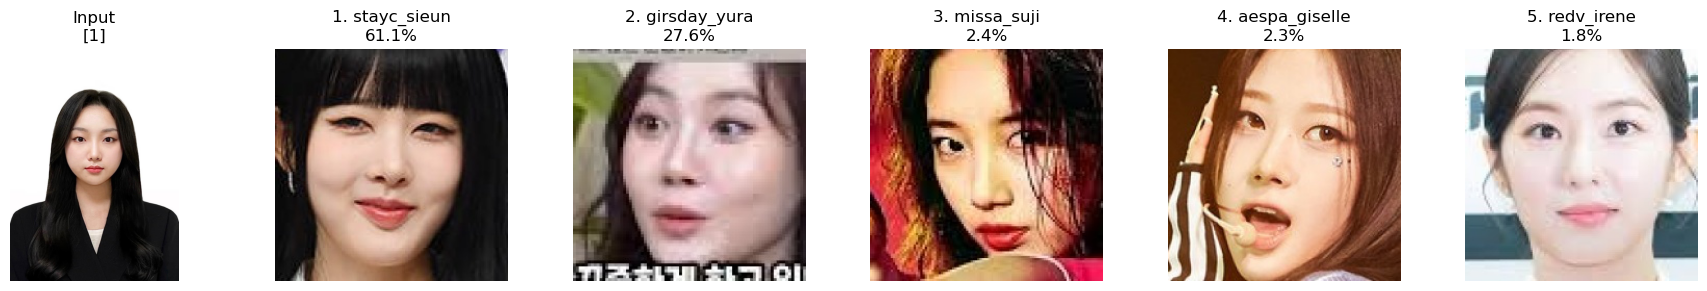


== [2] hs.jpg ==


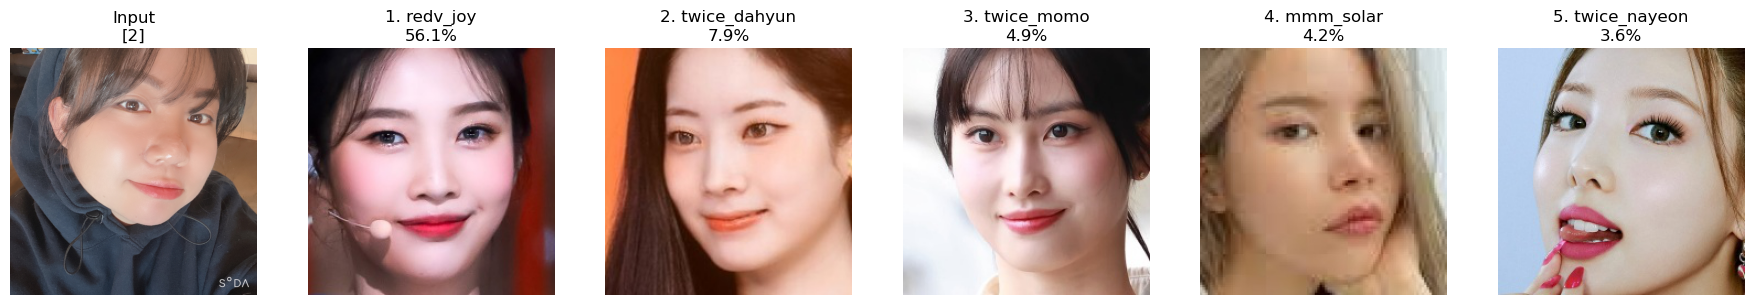


== [3] kj.jpg ==


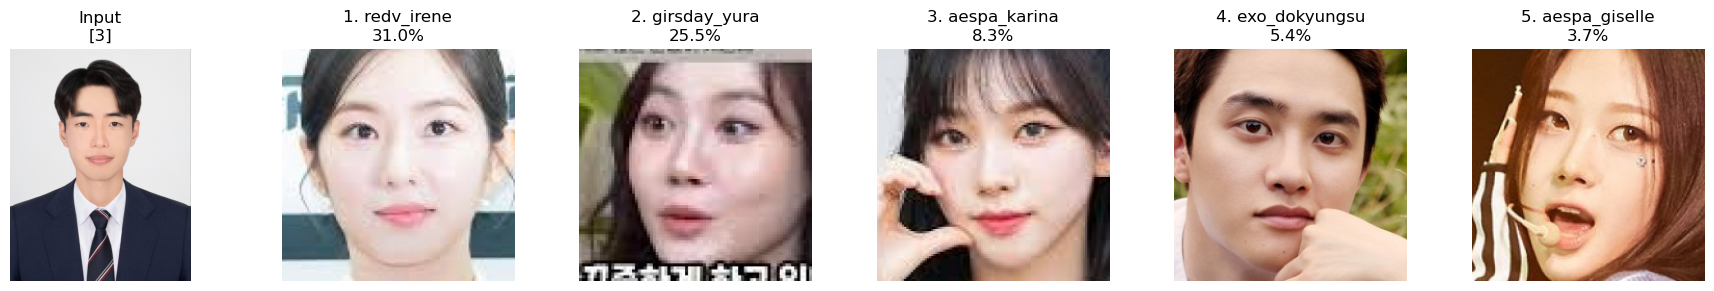


== [4] kml.jpg ==


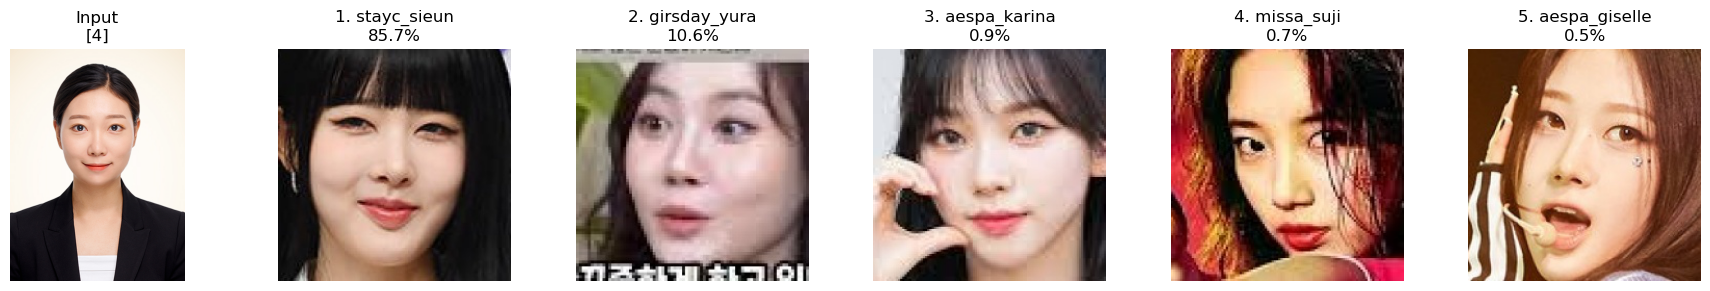

In [ ]:
# [7-2] 새 이미지 → Top-5 시각화
@torch.no_grad()
def predict_topk(model, image_path, classes, img_size=224, device=DEVICE, k=5):
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)
    model.eval()
    logits = model(x)
    probs  = torch.softmax(logits, dim=1)[0]
    topv, topi = torch.topk(probs, k=min(k, len(classes)))
    top = [(classes[i], float(v)) for i,v in zip(topi.cpu().tolist(), topv.cpu().tolist())]
    return img, top

def visualize_top5(model, image_path, classes, data_root, idx=None):
    inp_img, top = predict_topk(model, image_path, classes, IMG_SIZE, DEVICE, k=5)
    ncols = 1 + len(top)
    fig, axs = plt.subplots(1, ncols, figsize=(3*ncols, 3))

    # 입력 이미지
    axs[0].imshow(inp_img); axs[0].axis('off')
    axs[0].set_title(f"Input\n[{idx}]" if idx is not None else "Input")

    # Top-5 후보 (대표 이미지) + Top-1 강조
    for j, (name, prob) in enumerate(top, start=1):
        rep = sample_image_of_class(DATA_ROOT, name)
        if rep:
            rep_img = Image.open(rep).convert("RGB")
            axs[j].imshow(rep_img)
        else:
            axs[j].imshow(np.ones((IMG_SIZE,IMG_SIZE,3)))
        axs[j].axis('off')
        axs[j].set_title(f"{j}. {name}\n{prob*100:.1f}%")
        if j == 1:
            for sp in axs[j].spines.values():
                sp.set_edgecolor('red'); sp.set_linewidth(3)

    plt.tight_layout(); plt.show()

# NEW_IMAGE_DIR의 모든 이미지 enumerate하여 시각화
for idx, p in enumerate(Path(NEW_IMAGE_DIR).glob("*")):
    if is_image(p):
        print(f"\n== [{idx}] {p.name} ==")
        visualize_top5(model, str(p), classes, DATA_ROOT, idx=idx)


[8] 폴더라벨 일치율 점검 <hr>

In [ ]:
# [8-1] 폴더라벨 일치율 (옵션)
@torch.no_grad()
def folder_label_consistency(model, ds: Dataset, device=DEVICE):
    dl = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
    model.eval()
    tot, cor = 0, 0
    for imgs, labs, _p in dl:
        imgs, labs = imgs.to(device), labs.to(device)
        pred = model(imgs).argmax(1)
        cor += (pred==labs).sum().item()
        tot += imgs.size(0)
    return cor/max(tot,1)

print(f"Folder-label Consistency (Train): {folder_label_consistency(model, train_ds)*100:.2f}%")
print(f"Folder-label Consistency (Valid): {folder_label_consistency(model, val_ds)*100:.2f}%")


Folder-label Consistency (Train): 39.30%
Folder-label Consistency (Valid): 28.39%


[8] 새로운 이미지 예측 (닮은 꼴 연예인 찾기) <hr>

In [ ]:
# 새 이미지 vs 예측 연예인(Top-1) 시각화
@torch.no_grad()
def visualize_pair_top1(model, image_path, classes, data_root, img_size=224, device=DEVICE):
    """
    입력 이미지와, 모델이 고른 Top-1 클래스의 대표 이미지를 나란히 보여줍니다.
    """
    # Top-1 예측 얻기
    inp_img, top = predict_topk(model, image_path, classes, img_size=img_size, device=device, k=1)
    top1_class, top1_prob = top[0]

    # 해당 클래스에서 대표 이미지 하나 선택
    rep_path = sample_image_of_class(data_root, top1_class)
    rep_img  = Image.open(rep_path).convert("RGB") if rep_path else Image.new("RGB", (img_size, img_size), color=(255,255,255))

    # 시각화
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(inp_img); axs[0].axis("off")
    axs[0].set_title(f"Input\n{Path(image_path).name}")

    axs[1].imshow(rep_img); axs[1].axis("off")
    axs[1].set_title(f"Predicted: {top1_class}\n{top1_prob*100:.1f}%")

    # Top-1 강조용 테두리
    for sp in axs[1].spines.values():
        sp.set_edgecolor('red'); sp.set_linewidth(3)

    plt.tight_layout(); plt.show()


# 이미 제공했던 Top-5 그리드 시각화
@torch.no_grad()
def visualize_top5(model, image_path, classes, data_root, img_size=224, device=DEVICE):
    """
    입력 이미지 + Top-5 예측 클래스 대표 이미지들을 가로로 나란히 표시.
    Top-1은 붉은 테두리로 강조.
    """
    inp_img, top = predict_topk(model, image_path, classes, img_size=img_size, device=device, k=5)
    ncols = 1 + len(top)
    fig, axs = plt.subplots(1, ncols, figsize=(3*ncols, 3))

    # 입력 이미지
    axs[0].imshow(inp_img); axs[0].axis('off')
    axs[0].set_title(f"Input\n{Path(image_path).name}")

    # Top-5 후보
    for j, (name, prob) in enumerate(top, start=1):
        rep_path = sample_image_of_class(data_root, name)
        if rep_path:
            rep_img = Image.open(rep_path).convert("RGB")
            axs[j].imshow(rep_img)
        else:
            axs[j].imshow(np.ones((img_size, img_size, 3)))
        axs[j].axis('off')
        axs[j].set_title(f"{j}. {name}\n{prob*100:.1f}%")
        if j == 1:
            for sp in axs[j].spines.values():
                sp.set_edgecolor('red'); sp.set_linewidth(3)

    plt.tight_layout(); plt.show()



=== de.jpg ===


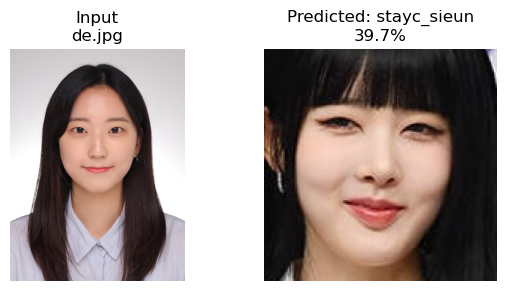

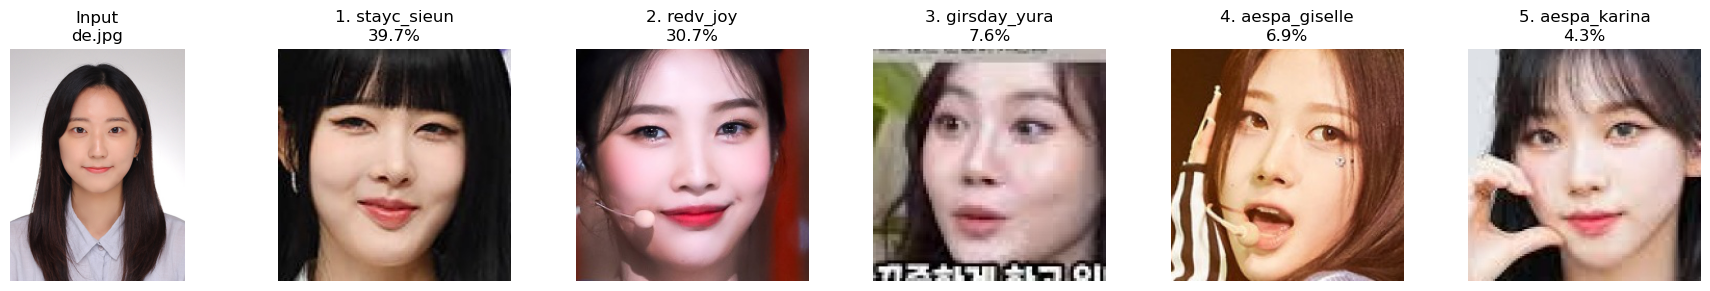


=== hr.jpg ===


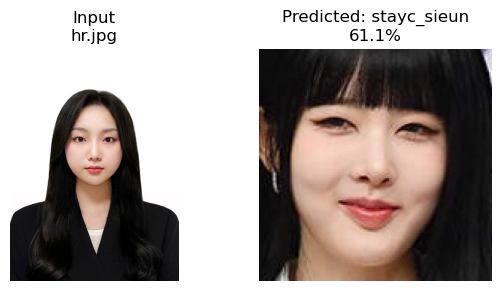

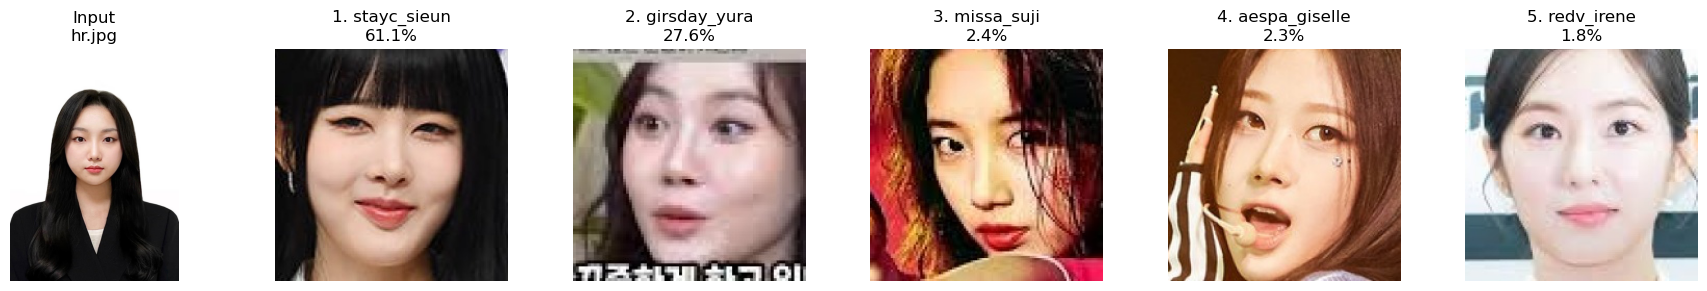


=== hs.jpg ===


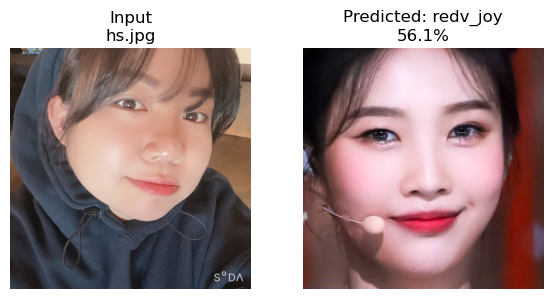

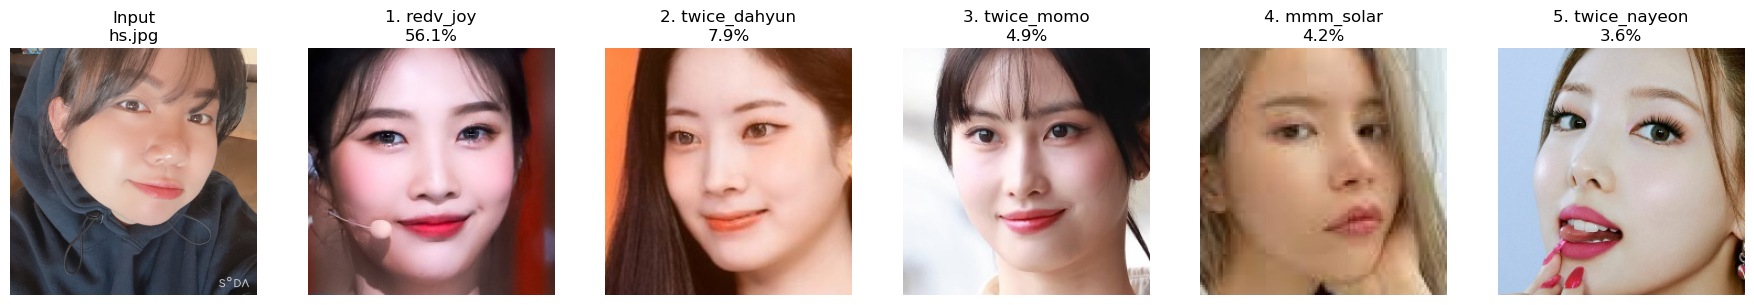


=== kj.jpg ===


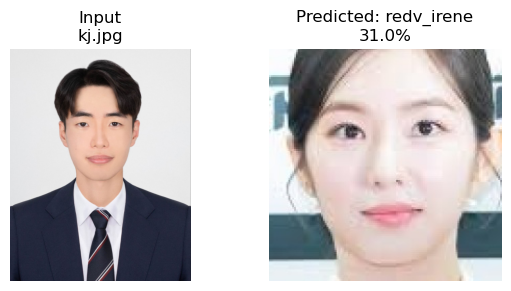

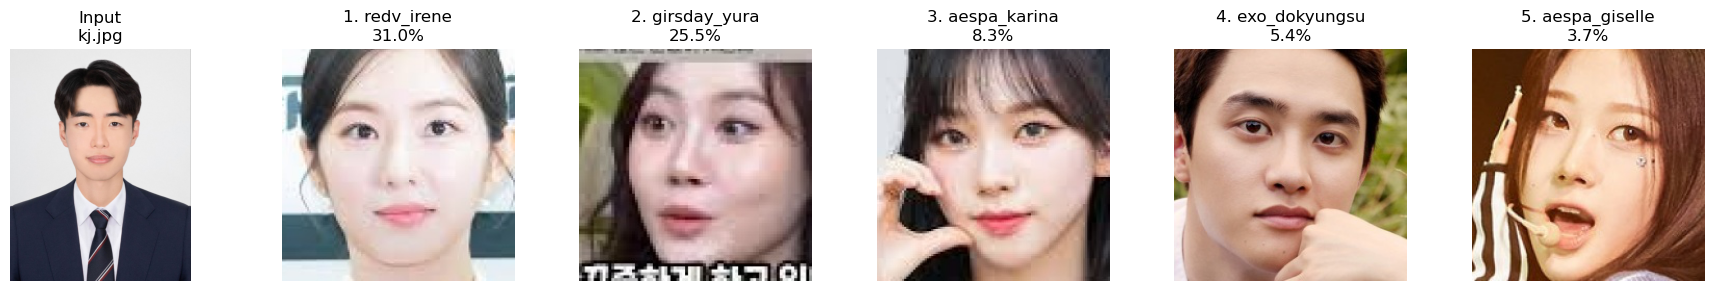


=== kml.jpg ===


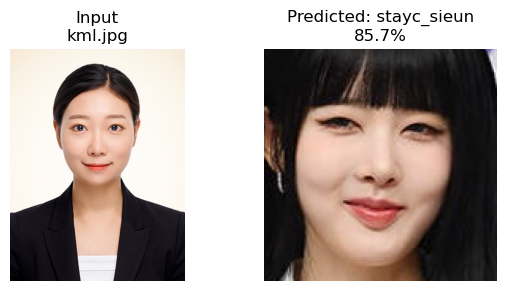

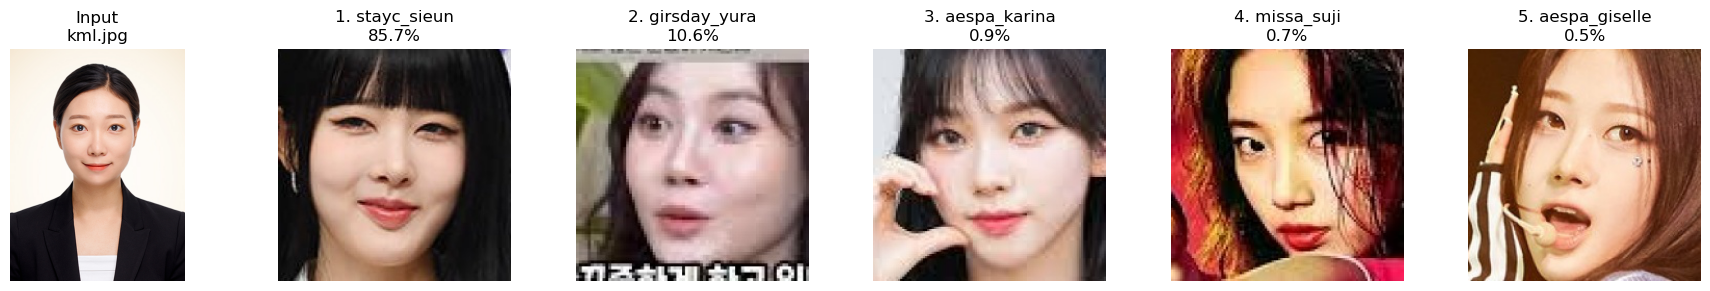

In [ ]:
# NEW_IMAGE_DIR 안의 모든 새 이미지
for p in Path(NEW_IMAGE_DIR).glob("*"):
    if is_image(p):
        print(f"\n=== {p.name} ===")
        visualize_pair_top1(model, str(p), classes, DATA_ROOT, img_size=IMG_SIZE, device=DEVICE)
        # Top-5 
        visualize_top5(model, str(p), classes, DATA_ROOT, img_size=IMG_SIZE, device=DEVICE)


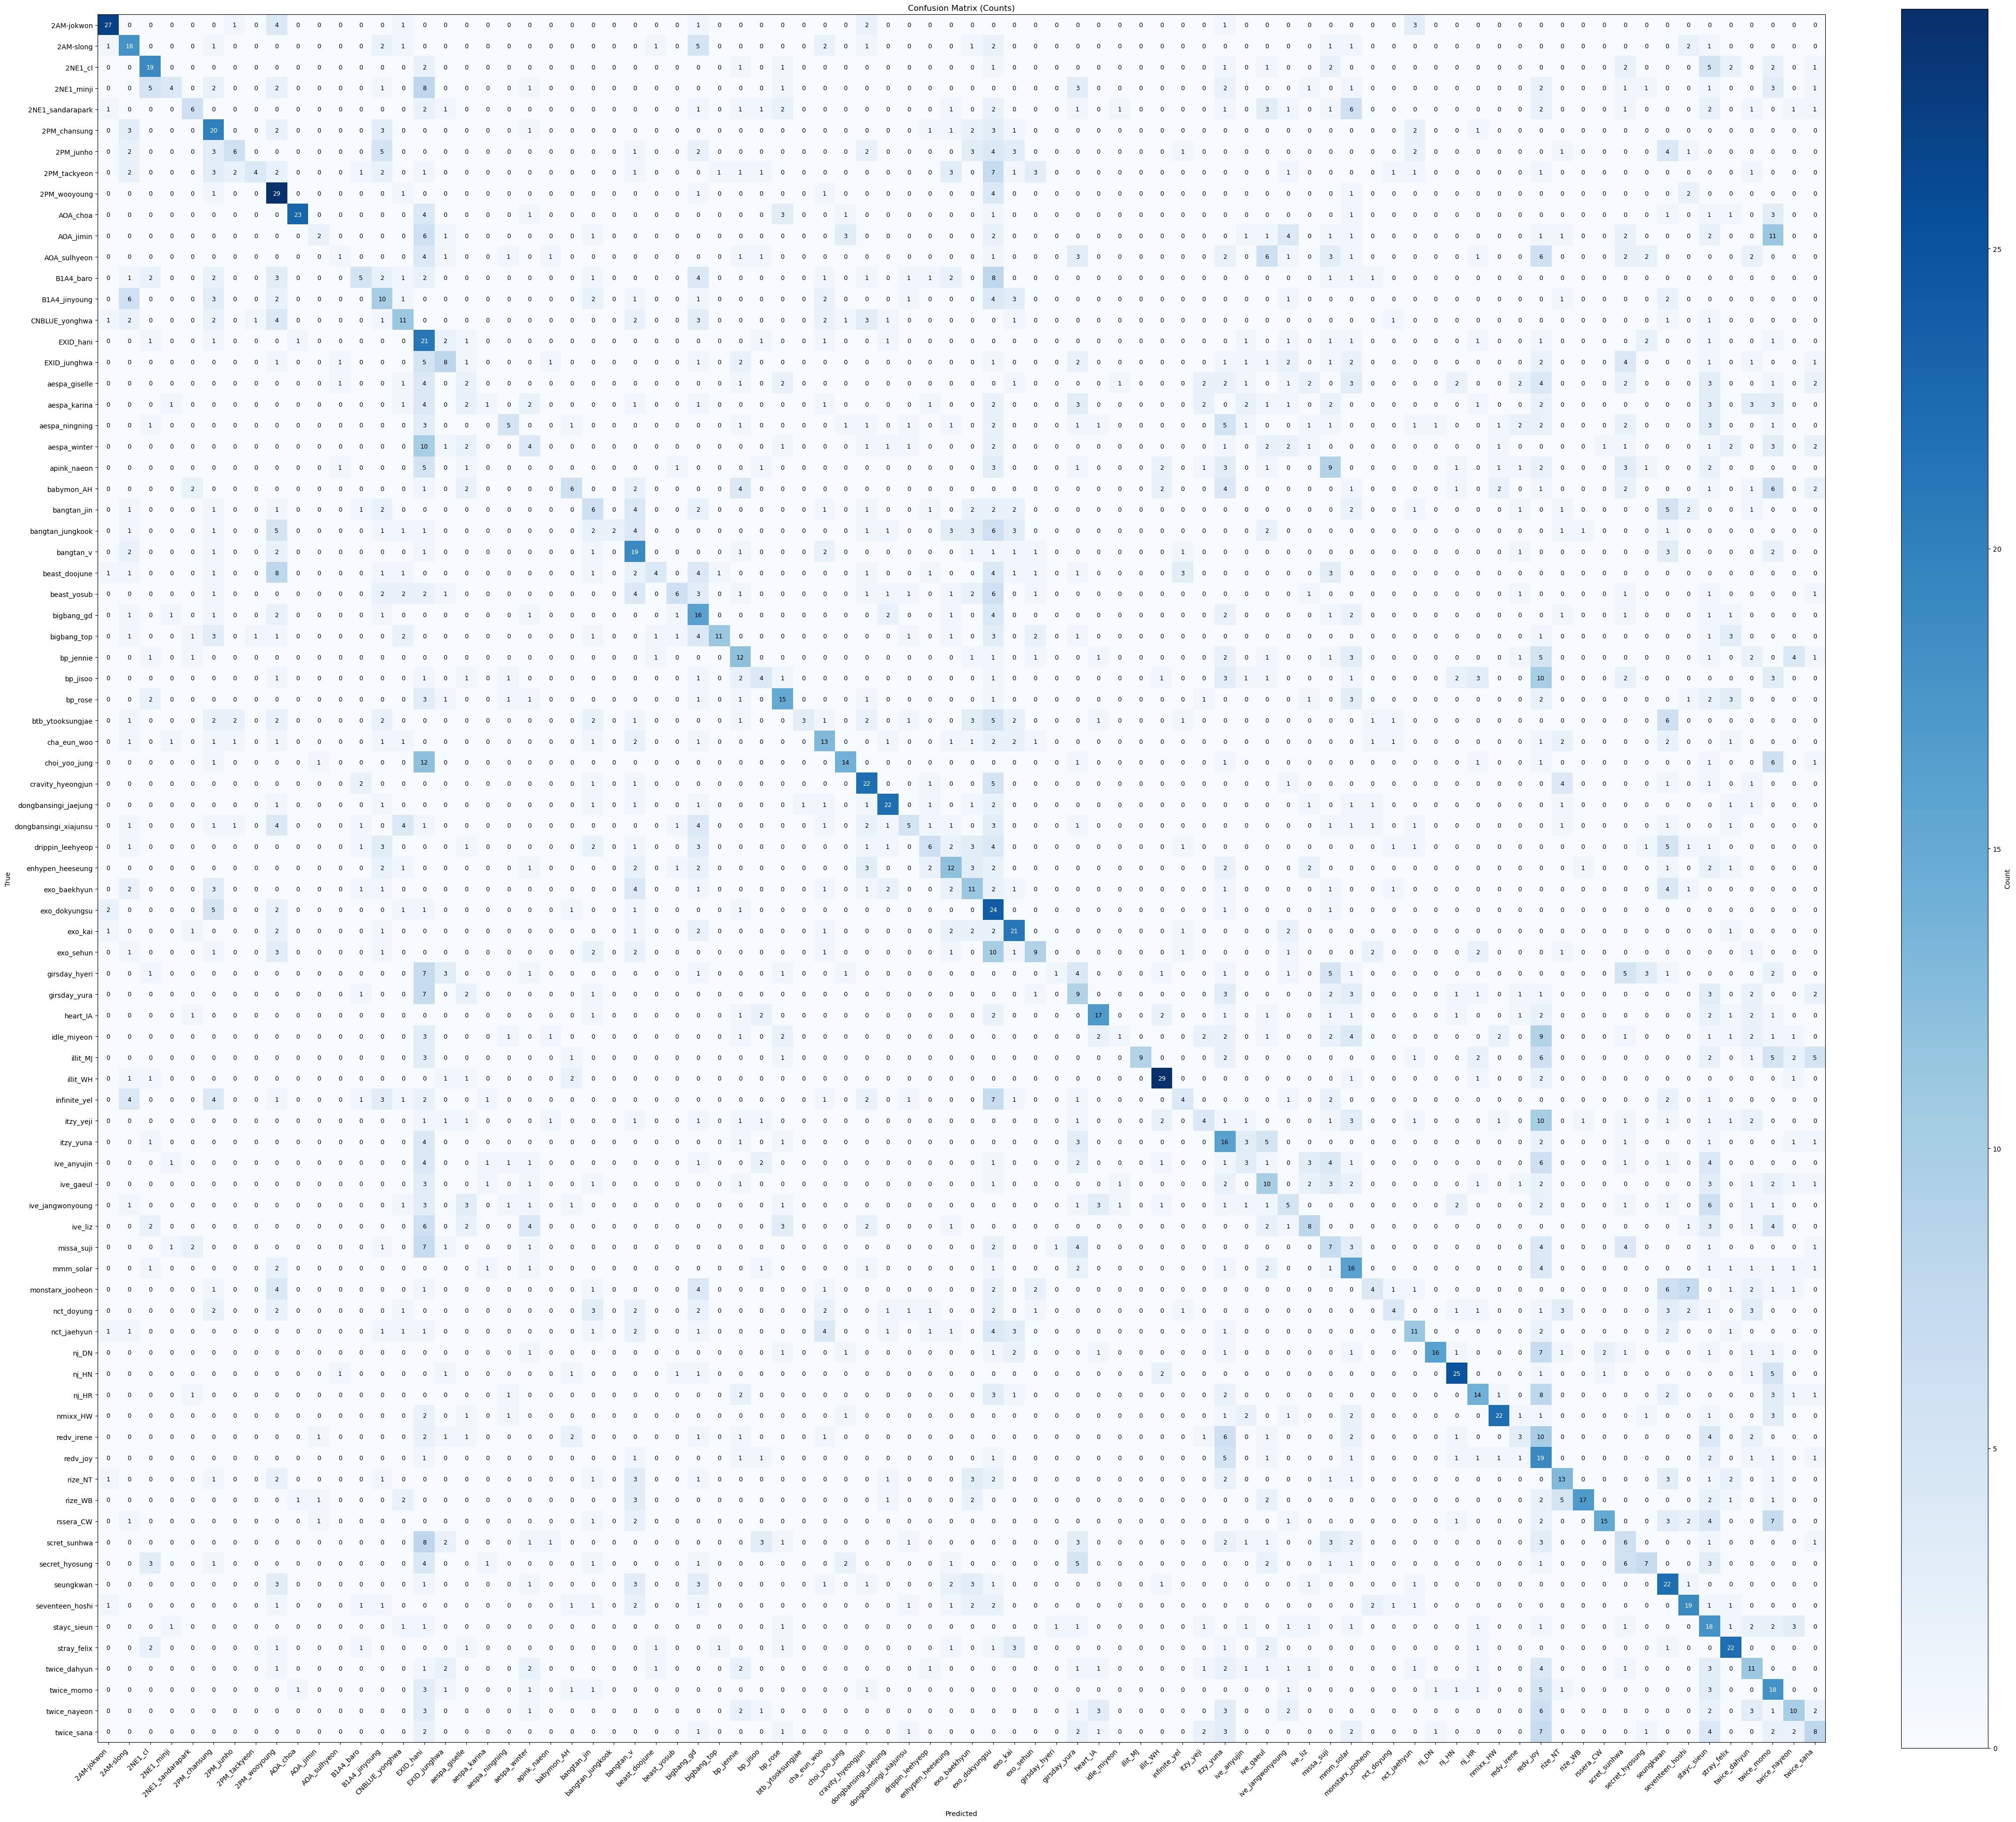

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))

fig, ax = plt.subplots(figsize=(max(8, len(classes)*0.5), max(6, len(classes)*0.5)))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix (Counts)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)

# 컬러바
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Count")

# 셀 안에 숫자(카운트) 표시
thr = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        ax.text(j, i, f"{val}", ha="center", va="center",
                color="white" if val > thr else "black", fontsize=9)

plt.tight_layout()
plt.show()


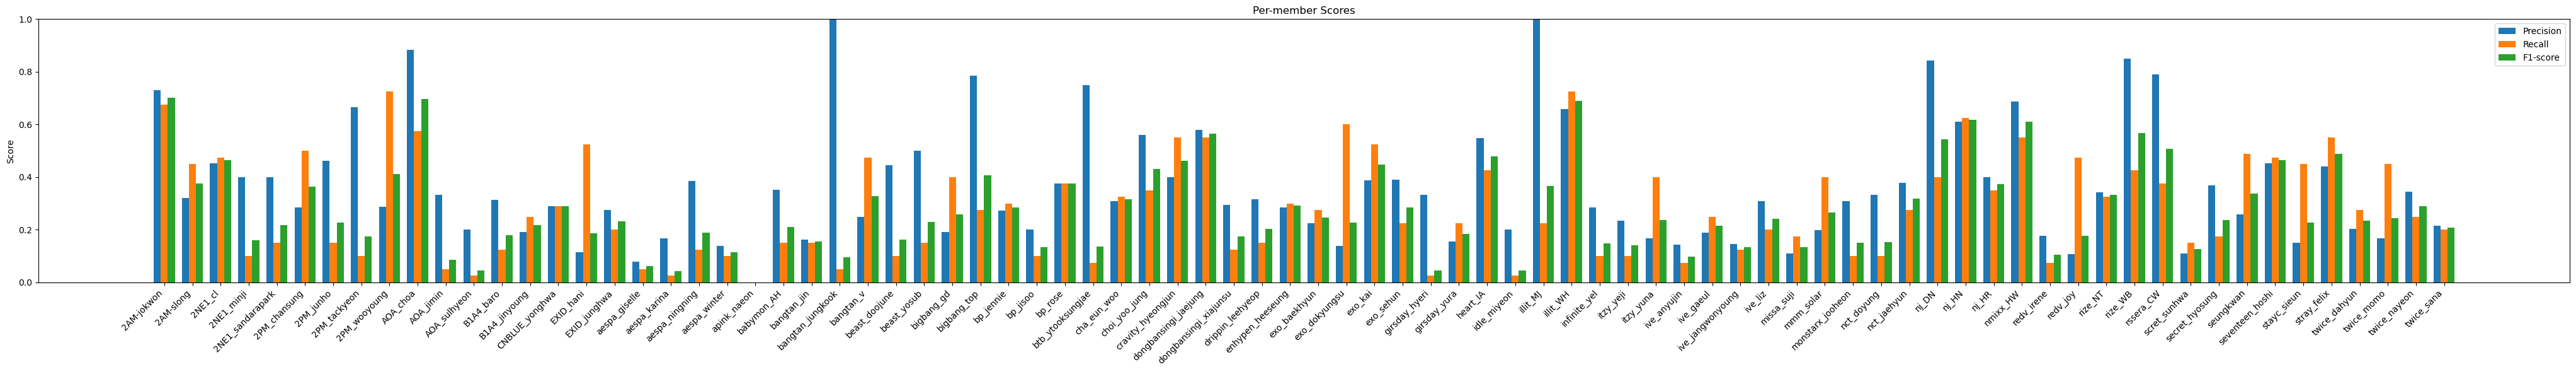

2AM-jokwon           | support=  40 | P=0.730 R=0.675 F1=0.701
2AM-slong            | support=  40 | P=0.321 R=0.450 F1=0.375
2NE1_cl              | support=  40 | P=0.452 R=0.475 F1=0.463
2NE1_minji           | support=  40 | P=0.400 R=0.100 F1=0.160
2NE1_sandarapark     | support=  40 | P=0.400 R=0.150 F1=0.218
2PM_chansung         | support=  40 | P=0.286 R=0.500 F1=0.364
2PM_junho            | support=  40 | P=0.462 R=0.150 F1=0.226
2PM_tackyeon         | support=  40 | P=0.667 R=0.100 F1=0.174
2PM_wooyoung         | support=  40 | P=0.287 R=0.725 F1=0.411
AOA_choa             | support=  40 | P=0.885 R=0.575 F1=0.697
AOA_jimin            | support=  40 | P=0.333 R=0.050 F1=0.087
AOA_sulhyeon         | support=  40 | P=0.200 R=0.025 F1=0.044
B1A4_baro            | support=  40 | P=0.312 R=0.125 F1=0.179
B1A4_jinyoung        | support=  40 | P=0.192 R=0.250 F1=0.217
CNBLUE_yonghwa       | support=  38 | P=0.289 R=0.289 F1=0.289
EXID_hani            | support=  40 | P=0.114 R=0.525 F

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(classes))), zero_division=0
)

x = np.arange(len(classes))
w = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(classes)*0.5), 6))
ax.bar(x - w, prec, width=w, label="Precision")
ax.bar(x,     rec,  width=w, label="Recall")
ax.bar(x + w, f1,   width=w, label="F1-score")

ax.set_title("Per-member Scores")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

# 서포트(클래스별 샘플 수)도 같이 보고 싶다면:
for i, c in enumerate(classes):
    print(f"{c:20s} | support={support[i]:4d} | P={prec[i]:.3f} R={rec[i]:.3f} F1={f1[i]:.3f}")
